In [1]:
import quante as qt

In [2]:
import quante as qt

a, b = 1, [1, 2, 3]
show(a, b)

a: 1; b: [1, 2, 3]


## 保存日志

通过在项目最开始运行：

In [3]:
qt.basicfun.set_logging(savelog=False, logtime=True)

可以将所有 `qt.basicfun.println`/`show` 的输出保存到 log 文件中，同时记录时间。

报错信息同样会记录到 log 文件中

In [4]:
show("hello world")

2025-06-11 23:04:20,474: hello world


In [5]:
qt.basicfun.set_logging(savelog=False, logtime=False)
show("hello world")

hello world


In [6]:
a = [1,2,3]
b = [4,5,6]
show(a, b)

a: [1, 2, 3]; b: [4, 5, 6]


In [7]:
a = [1,2,3]
b = 1
show(
    a,
    b
)

a: [1, 2, 3]; b: 1


In [8]:
a, b = [1,2,3], 1
show()

a: [1, 2, 3]; b: 1


In [9]:
qt.basicfun.set_show(arg_name=False)
a = [1,2,3]
b = 1
show(
    a,
    b,
)

[1, 2, 3]
1


## 数据保存

In [10]:
import numpy as np
a = np.random.randn(10,10)
qt.basicfun.isave("data.h5")

In [11]:
a, = qt.basicfun.iload("data.h5")  # 这样可以得到储存的数据

也支持多个数据的的保存和导入

In [12]:
a = [1,2,3]
b = np.random.randn(10,10)

# c, d 不能被 hdf5 直接保存，将会被序列化，失去可视化的效果
c = [a, b]
class D:
    def __init__(self, x):
        self.x = x
d = D(10)

qt.basicfun.isave("data.h5", a, b, c, d)  

In [13]:
a, b, c, d = qt.basicfun.iload("data.h5")

如果涉及到 group，可以：

In [14]:
a = np.random.randn(10,10)
qt.basicfun.save_hdf5("data.h5", "/", {"a": a})

('data.h5', '/')

In [16]:
a = qt.basicfun.load_hdf5('data.h5', '/', 'a')

这种写法下，如果需要 load 更多元素，可以：

In [17]:
a = qt.basicfun.load_hdf5('data.h5', '/', '/')

## 画图预设

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [18]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [19]:
qt.basicfun.print_memory_usage(a)

7.63 MB


matplotlib 默认的画图风格为：

Text(0, 0.5, '$\\sin x$')

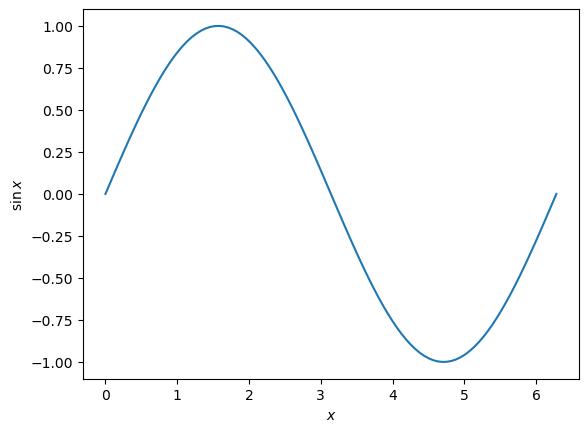

In [20]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

通过 `plt_style_use` 可以改变风格：

Text(0, 0.5, '$\\sin x$')

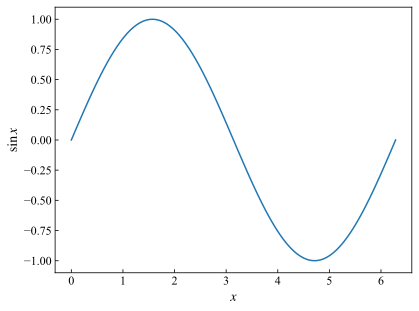

In [22]:
import matplotlib.pyplot as plt
import numpy as np
qt.basicfun.plt_style_use()

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

Text(0, 0.5, '$\\sin x$')

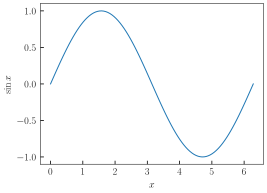

In [23]:
import matplotlib.pyplot as plt
import numpy as np
qt.basicfun.plt_style_use('science')

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [24]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [25]:
qt.basicfun.print_memory_usage(a)

7.63 MB


## 代码调试工具

### 显示代码运行运行的时间

In [26]:
import numpy as np

def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

with Timer(myfun, singlestep):
    myfun(100)

Timer unit: 0.001 s

Total time: 0.0091575 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_2476\2100961480.py
Function: singlestep at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           def singlestep(a, i, j):
     4     10000          6.5      0.0     71.0      a = np.sin(a)
     5     10000          2.7      0.0     29.0      return a + i + j

Total time: 0.020512 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_2476\2100961480.py
Function: myfun at line 7

Line #      Hits         Time  Per Hit   % Time  Line Contents
     7                                           def myfun(dim):
     8         1          0.1      0.1      0.6      mat = np.random.randn(dim,dim)
     9       101          0.0      0.0      0.1      for i in range(dim):
    10     10100          1.7      0.0      8.1          for j in range(dim):
    11     10000         18.7      0.0     91.2              mat[i,j] = singlestep(mat[i,j], i, j)

显示了每一行运行需要的时间

如果是 py 文件中，可以使用 profile 装饰器

```python
@bf.profile()
def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

@bf.profile()
def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

myfun(100)
```

## Dynamic Plot

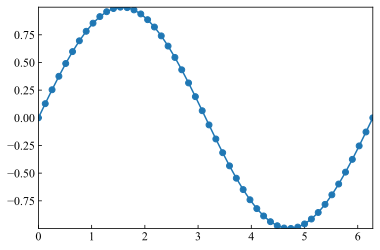

In [28]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

qt.basicfun.plt_style_use()
xs = np.linspace(0, 2*np.pi, 50)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
res = qt.basicfun.DynamicPlot(xs, ax, 'o-', label='sin(x)')
for x in xs:
    res.append(np.sin(x))

array([[ 1.        ,  0.99798668,  0.99195481,  0.9819287 ,  0.9679487 ,  0.95007112,  0.92836793,  0.90292654,  0.87384938,  0.84125353,  0.80527026,  0.76604444,  0.72373404,  0.67850941,  0.63055267,  0.58005691,  0.52722547,  0.47227107,  0.41541501,  0.35688622,  0.29692038,  0.23575894,  0.17364818,  0.1108382 ,  0.04758192, -0.01586596, -0.07924996, -0.14231484, -0.20480667, -0.26647381, -0.32706796, -0.38634513, -0.44406661, -0.5       , -0.55392006, -0.60560969, -0.65486073, -0.70147489, -0.74526445, -0.78605309, -0.82367658, -0.85798341, -0.88883545, -0.91610846, -0.93969262, -0.95949297, -0.97542979, -0.98743889, -0.99547192, -0.99949654, -0.99949654, -0.99547192, -0.98743889, -0.97542979, -0.95949297, -0.93969262, -0.91610846, -0.88883545, -0.85798341, -0.82367658, -0.78605309, -0.74526445, -0.70147489, -0.65486073, -0.60560969, -0.55392006, -0.5       , -0.44406661, -0.38634513, -0.32706796, -0.26647381, -0.20480667, -0.14231484, -0.07924996, -0.01586596,  0.04758192,  0.1

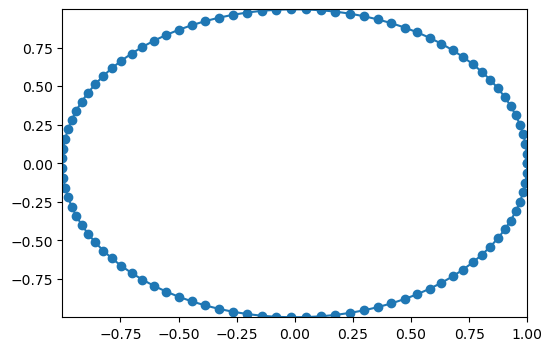

In [8]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 100)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
dp = qt.basicfun.DynamicPlot(xs, ax, 'o-', label='sin(x)')
for x in xs:
    dp.append((np.cos(x), np.sin(x)))
dp

array([[ 0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ],
       [ 0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761],
       [ 0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775],
       [ 0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ],
       [ 0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014],
       [-0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014],
       [-0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 ],
       [-0.98480775, -0.642

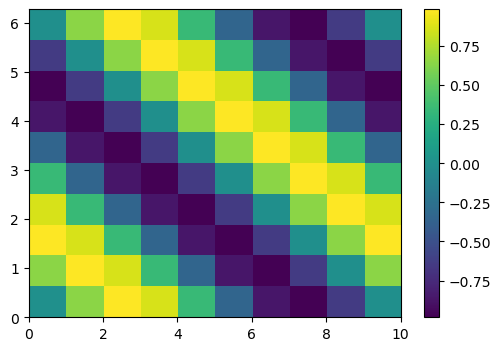

In [9]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 10)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
dp = qt.basicfun.DynamicPlot(xs, ax).set(legend=True)
for x in xs:
    dp.append([np.sin(x + phi) for phi in np.linspace(0, 2*np.pi, 10)])
dp

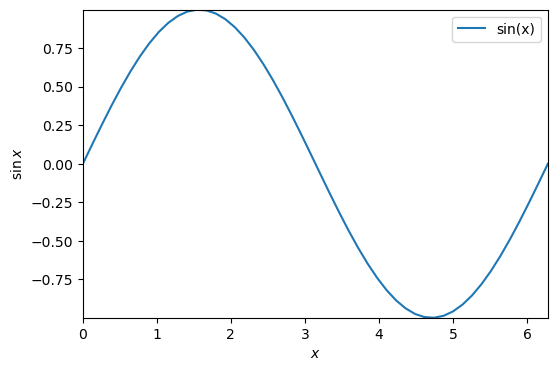

In [18]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 50)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\sin x$')
res = qt.basicfun.DynamicPlot(xs, ax, label='sin(x)')
res.set(legend=True)
for x in xs:
    res.append(np.sin(x))